# Full-volume test evaluation

Full-volume inference for one frozen checkpoint on the held-out test split. The same inference settings are used for each experiment, with no threshold tuning.

In [1]:
from pathlib import Path
import os
import sys
from functools import partial

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)
existing_path_candidates = paths_io.candidates

Project: /home/mandrakedrink/projects/research_ts_bs


In [2]:
from brats_pipeline.common import seed_all, guard_output_directory
from brats_pipeline.data import (
    jp, load_nii as _load_nii, normalize_nonzero, remap_brats_labels,
    xyz_to_dhw, dhw_to_xyz, best_tumor_slice_dhw,
)
from brats_pipeline.inference import (
    create_segresnet, load_trusted_checkpoint, extract_model_state_dict,
    predict_labels_dhw, brats_region_dice_np, brats_region_voxels,
)
load_nii = partial(_load_nii, project_root=PROJECT_ROOT)

## Imports

In [3]:
import os
import json
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import nibabel as nib

import torch

from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference

from pathlib import Path

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


## Test experiment configuration

In [4]:

# Experiment evaluated in this run.

SELECTED_EXPERIMENT_KEY = "fedprox_s32_cew"
PROJECT_ROOT_HINT = str(PROJECT_ROOT)
EVALUATION_SPLIT = "test"
METRICS_FILENAME = "full_volume_test_metrics.csv"

COMMON_MODEL_KWARGS = {
    "spatial_dims": 3,
    "in_channels": 4,
    "out_channels": 4,
    "init_filters": 32,
    "blocks_down": (1, 2, 2, 4),
    "blocks_up": (1, 1, 1),
    "dropout_prob": 0.1,
}

EXPERIMENT_PRESETS = {
    "centralized_s32_cew": {
        "experiment_name": "Centralized SegResNet32 final CE-weighted — TEST",
        "experiment_suffix": "centralized_segresnet32_final_ceweighted_test",
        "checkpoint": "models/centralized_segresnet32_final/segresnet_final_best_mean_dice.pt",
        "save_dir": "models/centralized_segresnet32_final/full_volume_inference_test",
        "model_name": "segresnet",
        "model_kwargs": COMMON_MODEL_KWARGS,
        # Optional comparison baseline; leave unset for an independent run.
        "baseline_name": None,
        "baseline_suffix": None,
        "baseline_metrics": None,
    },

    "fedavg_s32_cew": {
        "experiment_name": "FedAvg SegResNet32 final CE-weighted — TEST",
        "experiment_suffix": "fedavg_segresnet32_final_ceweighted_test",
        "checkpoint": "models/federated_fedavg_segresnet32_final/fedavg_best_mean_dice.pt",
        "save_dir": "models/federated_fedavg_segresnet32_final/full_volume_inference_test",
        "model_name": "segresnet",
        "model_kwargs": COMMON_MODEL_KWARGS,
        # Compare with the centralized reference when available.
        "baseline_name": "Centralized SegResNet32 final CE-weighted — TEST",
        "baseline_suffix": "centralized_segresnet32_final_ceweighted_test",
        "baseline_metrics": "models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
    },

    "fedprox_s32_cew": {
        "experiment_name": "FedProx SegResNet32 final CE-weighted — TEST",
        "experiment_suffix": "fedprox_segresnet32_final_ceweighted_test",
        "checkpoint": "models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt",
        "save_dir": "models/federated_fedprox_segresnet32_final/full_volume_inference_test",
        "model_name": "segresnet",
        "model_kwargs": COMMON_MODEL_KWARGS,
        # Compare with FedAvg when available.
        "baseline_name": "FedAvg SegResNet32 final CE-weighted — TEST",
        "baseline_suffix": "fedavg_segresnet32_final_ceweighted_test",
        "baseline_metrics": "models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
    },

    "centralized_v2_s16": {
        "experiment_name": "Centralized V2 SegResNet16 — TEST",
        "experiment_suffix": "centralized_v2_segresnet16_test",
        "checkpoint": "models/centralized_baseline_v2/best_model.pt",
        "save_dir": "models/centralized_baseline_v2/full_volume_inference_test",
        "model_name": "segresnet",
        "model_kwargs": {
            **COMMON_MODEL_KWARGS,
            "init_filters": 16,
        },
        "baseline_name": None,
        "baseline_suffix": None,
        "baseline_metrics": None,
    },
}

if SELECTED_EXPERIMENT_KEY not in EXPERIMENT_PRESETS:
    raise KeyError(
        f"Unknown SELECTED_EXPERIMENT_KEY={SELECTED_EXPERIMENT_KEY!r}. "
        f"Available: {list(EXPERIMENT_PRESETS)}"
    )


preset = EXPERIMENT_PRESETS[SELECTED_EXPERIMENT_KEY]

CFG = {
    "project_root_hint": PROJECT_ROOT_HINT,
    "manifest": str(PROJECT_ROOT / 'data/processed/manifest_4clients_seed42.csv'),
    "evaluation_split": EVALUATION_SPLIT,
    "metrics_filename": METRICS_FILENAME,

    **preset,

    # Sliding-window inference settings.
    "roi_size": (128, 128, 128),
    "sw_batch_size": 1,
    "overlap": 0.5,

    # Visualization settings.
    "visualize_tcga_lgg_worst_et_cases": True,
    "n_visual_cases": 3,

    # Set for smoke tests; None evaluates the full split.
    "max_cases": None,

    # Print checkpoint metadata when available.
    "print_checkpoint_metadata": True,
}

# Resolve checkpoint and optional baseline.
CFG["checkpoint_abs"] = str(resolve_existing_path(CFG["checkpoint"], required=True, label="checkpoint"))
if CFG.get("baseline_metrics") is not None:
    baseline_abs = resolve_existing_path(
        CFG["baseline_metrics"],
        required=False,
        label="baseline_metrics"
    )
    CFG["baseline_metrics_abs"] = str(baseline_abs) if baseline_abs is not None else None
else:
    CFG["baseline_metrics_abs"] = None

os.makedirs(CFG["save_dir"], exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("selected:", SELECTED_EXPERIMENT_KEY)
print("evaluation_split:", CFG["evaluation_split"])
print("metrics_filename:", CFG["metrics_filename"])
print("experiment:", CFG["experiment_name"])
print("checkpoint:", CFG["checkpoint"])
print("checkpoint_abs:", CFG["checkpoint_abs"])
print("save_dir:", CFG["save_dir"])
print("model:", CFG["model_name"])
print("model_kwargs:", CFG["model_kwargs"])
print("baseline:", CFG["baseline_name"])
print("baseline_metrics:", CFG["baseline_metrics"])
print("baseline_metrics_abs:", CFG["baseline_metrics_abs"])
print("max_cases:", CFG["max_cases"])
print("device:", device)

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

CFG

selected: fedprox_s32_cew
evaluation_split: test
metrics_filename: full_volume_test_metrics.csv
experiment: FedProx SegResNet32 final CE-weighted — TEST
checkpoint: models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt
checkpoint_abs: /home/mandrakedrink/projects/research_ts_bs/notebooks/models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt
save_dir: models/federated_fedprox_segresnet32_final/full_volume_inference_test
model: segresnet
model_kwargs: {'spatial_dims': 3, 'in_channels': 4, 'out_channels': 4, 'init_filters': 32, 'blocks_down': (1, 2, 2, 4), 'blocks_up': (1, 1, 1), 'dropout_prob': 0.1}
baseline: FedAvg SegResNet32 final CE-weighted — TEST
baseline_metrics: models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
baseline_metrics_abs: /home/mandrakedrink/projects/research_ts_bs/models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
max_cases: None
device: cuda
gp

{'project_root_hint': '/home/mandrakedrink/projects/research_ts_bs',
 'manifest': '/home/mandrakedrink/projects/research_ts_bs/data/processed/manifest_4clients_seed42.csv',
 'evaluation_split': 'test',
 'metrics_filename': 'full_volume_test_metrics.csv',
 'experiment_name': 'FedProx SegResNet32 final CE-weighted — TEST',
 'experiment_suffix': 'fedprox_segresnet32_final_ceweighted_test',
 'checkpoint': 'models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt',
 'save_dir': 'models/federated_fedprox_segresnet32_final/full_volume_inference_test',
 'model_name': 'segresnet',
 'model_kwargs': {'spatial_dims': 3,
  'in_channels': 4,
  'out_channels': 4,
  'init_filters': 32,
  'blocks_down': (1, 2, 2, 4),
  'blocks_up': (1, 1, 1),
  'dropout_prob': 0.1},
 'baseline_name': 'FedAvg SegResNet32 final CE-weighted — TEST',
 'baseline_suffix': 'fedavg_segresnet32_final_ceweighted_test',
 'baseline_metrics': 'models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_vol

## Save evaluation configuration

In [44]:
eval_config_path = os.path.join(CFG["save_dir"], "full_volume_eval_config.json")

with open(eval_config_path, "w", encoding="utf-8") as f:
    json.dump(CFG, f, indent=2, default=str)

print("saved eval config:", eval_config_path)

saved eval config: models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_eval_config.json


## Reproducibility seed

In [6]:
seed_all(42)

## Load manifest and configured evaluation split

In [7]:
mf_df = pd.read_csv(CFG["manifest"])

print("manifest:", mf_df.shape)
print(mf_df.groupby(["client_domain", "split"]).size())

split_name = CFG.get("evaluation_split", "val")
eval_df = mf_df[mf_df["split"] == split_name].reset_index(drop=True).copy()

# Compatibility alias: the original notebook used val_df everywhere.
# For this TEST notebook, val_df == eval_df == selected split.
val_df = eval_df

if len(eval_df) == 0:
    raise ValueError(f"No cases found for split={split_name!r}")

print(f"selected split: {split_name}")
print("eval:", eval_df.shape)
print(eval_df.groupby("client_domain").size())

eval_df.head()

manifest: (1060, 4)
client_domain  split
TCGA-GBM       test      20
               train     72
               val       10
TCGA-LGG       test      13
               train     46
               val        6
UCSF-PDGM      test      76
               train    268
               val       38
UPENN-GBM      test     102
               train    358
               val       51
dtype: int64
selected split: test
eval: (211, 4)
client_domain
TCGA-GBM      20
TCGA-LGG      13
UCSF-PDGM     76
UPENN-GBM    102
dtype: int64


,patient_id,paths,client_domain,split
0,BraTS2021_00003,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,test
1,BraTS2021_00009,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,test
2,BraTS2021_00014,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,test
3,BraTS2021_00016,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,test
4,BraTS2021_00019,"{""t1"": ""/home/mandrakedrink/projects/research_...",UCSF-PDGM,test


## Load one full patient case

In [8]:
def load_full_case(row, normalize=True, remap=True):
    """Load a normalized four-channel case for full-volume evaluation."""
    p = jp(row["paths"])

    images = []

    for m in ["t1", "t1ce", "t2", "flair"]:
        vol = load_nii(p[m], dtype=np.float32)

        if normalize:
            vol = normalize_nonzero(vol)

        images.append(vol)

    image_xyz = np.stack(images, axis=0).astype(np.float32)

    seg_xyz = load_nii(p["seg"], dtype=np.uint8)

    if remap:
        seg_xyz = remap_brats_labels(seg_xyz)

    image_dhw, seg_dhw = xyz_to_dhw(image_xyz, seg_xyz)

    return {
        "image_dhw": image_dhw,
        "seg_dhw": seg_dhw,
        "patient_id": row["patient_id"],
        "client_domain": row["client_domain"],
        "split": row["split"],
        "paths": p,
    }

## Sanity check: load first test case

In [9]:
case = load_full_case(val_df.iloc[0])

print(case["patient_id"])
print("image:", case["image_dhw"].shape)
print("seg:", case["seg_dhw"].shape)
print("labels:", np.unique(case["seg_dhw"]))

BraTS2021_00003
image: (4, 155, 240, 240)
seg: (155, 240, 240)
labels: [0 1 2 3]


## Model factory and checkpoint loading

In [10]:
def create_model(model_name, model_kwargs):
    """Build the configured segmentation model."""
    name = model_name.lower()

    if name == "segresnet":
        return create_segresnet(model_kwargs)

    raise ValueError(
        f"Unsupported model_name={model_name!r}. "
        "Add a new branch in create_model()."
    )


ckpt = load_trusted_checkpoint(CFG.get("checkpoint_abs", CFG["checkpoint"]), map_location=device)

model = create_model(
    model_name=CFG["model_name"],
    model_kwargs=copy.deepcopy(CFG["model_kwargs"]),
).to(device)

state_dict = extract_model_state_dict(ckpt)
model.load_state_dict(state_dict, strict=True)
model.eval()

print("experiment:", CFG["experiment_name"])
print("loaded checkpoint:", CFG.get("checkpoint_abs", CFG["checkpoint"]))

if CFG.get("print_checkpoint_metadata", True) and isinstance(ckpt, dict):
    print("checkpoint keys:", list(ckpt.keys()))
    print("checkpoint epoch:", ckpt.get("epoch"))
    print("checkpoint round:", ckpt.get("round"))
    print("best val loss:", ckpt.get("best_val_loss"))
    print("best val mean dice:", ckpt.get("best_val_mean_dice"))

    if "cfg" in ckpt:
        ckpt_cfg = ckpt["cfg"]
        print(
            "checkpoint cfg keys:",
            list(ckpt_cfg.keys()) if isinstance(ckpt_cfg, dict) else type(ckpt_cfg)
        )
        if isinstance(ckpt_cfg, dict):
            print("checkpoint init_filters:", ckpt_cfg.get("init_filters"))
            print("checkpoint patch_size:", ckpt_cfg.get("patch_size"))

total_params = sum(p.numel() for p in model.parameters())
print("model params:", f"{total_params:,}")

experiment: FedProx SegResNet32 final CE-weighted — TEST
loaded checkpoint: /home/mandrakedrink/projects/research_ts_bs/notebooks/models/federated_fedprox_segresnet32_final/fedprox_best_mean_dice.pt
checkpoint keys: ['model', 'round', 'cfg', 'history', 'client_weights', 'client_sizes', 'best_mean_dice', 'best_round', 'algorithm', 'fedprox_mu']
checkpoint epoch: None
checkpoint round: 78
best val loss: None
best val mean dice: None
checkpoint cfg keys: ['manifest', 'patch_size', 'batch_size', 'grad_accum_steps', 'num_workers', 'num_classes', 'in_channels', 'init_filters', 'lr', 'min_lr', 'weight_decay', 'grad_clip_norm', 'fed_rounds', 'min_rounds', 'early_stop_patience', 'early_stop_min_delta', 'local_epochs', 'fedprox_mu', 'max_client_batches', 'max_val_batches', 'p_et', 'p_tumor', 'p_foreground', 'p_random', 'use_augmentation', 'flip_prob', 'intensity_prob', 'scale_range', 'shift_range', 'noise_prob', 'noise_std', 'use_ce_weight', 'ce_weight', 'dice_loss_weight', 'ce_loss_weight', 'sa

## Full-volume sliding-window prediction

In [11]:
def predict_full_volume(model, image_dhw, device):
    return predict_labels_dhw(model, image_dhw, device,
        roi_size=CFG["roi_size"], sw_batch_size=CFG["sw_batch_size"],
        overlap=CFG["overlap"], mode="gaussian")

## Sanity check: predict one full test case

In [12]:
pred_dhw = predict_full_volume(
    model=model,
    image_dhw=case["image_dhw"],
    device=device,
)

print("pred:", pred_dhw.shape)
print("pred labels:", np.unique(pred_dhw))

/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autogr

pred: (155, 240, 240)
pred labels: [0 1 2 3]


## Sanity check: Dice for one case

In [13]:
dice_one = brats_region_dice_np(pred_dhw, case["seg_dhw"])
dice_one

{'dice_WT': 0.97920175394898,
 'dice_TC': 0.9766507959412224,
 'dice_ET': 0.9471723601541812}

## Visualization helpers

In [14]:
SEG_CMAP = ListedColormap([
    "#9B51E0",  # 1
    "#27AE60",  # 2
    "#F2994A",  # 3
])

SEG_NORM = BoundaryNorm(
    [0.5, 1.5, 2.5, 3.5],
    SEG_CMAP.N
)


def show_full_prediction(case, pred_dhw, title=None):
    """Display full-volume segmentation on one informative depth slice."""
    image = case["image_dhw"]
    target = case["seg_dhw"]

    z = best_tumor_slice_dhw(target)

    flair_slice = image[3, z]
    gt_slice = target[z]
    pred_slice = pred_dhw[z]

    if title is None:
        title = case["patient_id"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # FLAIR
    axes[0].imshow(flair_slice, cmap="gray")
    axes[0].set_title("FLAIR")
    axes[0].axis("off")

    # Ground truth
    axes[1].imshow(flair_slice, cmap="gray")

    gt_overlay = np.ma.masked_equal(gt_slice, 0)
    axes[1].imshow(
        gt_overlay,
        cmap=SEG_CMAP,
        norm=SEG_NORM,
        alpha=0.55,
        interpolation="nearest",
    )

    axes[1].set_title("Ground truth")
    axes[1].axis("off")

    # Prediction
    axes[2].imshow(flair_slice, cmap="gray")

    pred_overlay = np.ma.masked_equal(pred_slice, 0)
    axes[2].imshow(
        pred_overlay,
        cmap=SEG_CMAP,
        norm=SEG_NORM,
        alpha=0.55,
        interpolation="nearest",
    )

    axes[2].set_title("Prediction")
    axes[2].axis("off")

    fig.suptitle(f"{title} | slice={z}")
    plt.tight_layout()
    plt.show()

## Visual diagnostic check for one case

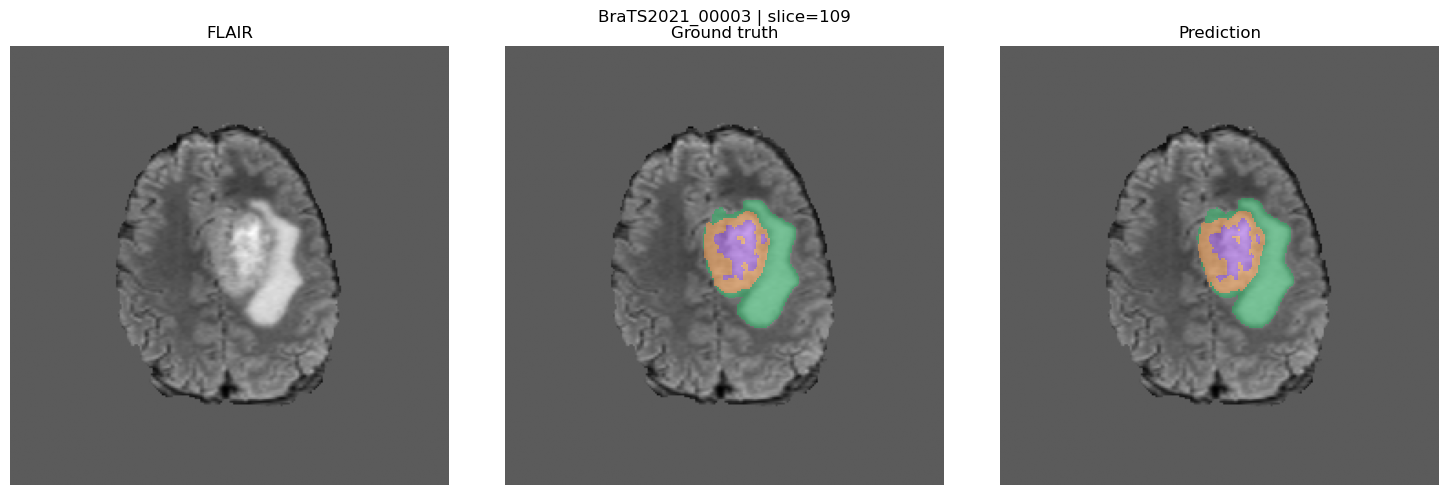

In [15]:
show_full_prediction(case, pred_dhw, title=case["patient_id"])

In [16]:
region_volumes_np = brats_region_voxels

## Full-volume evaluation function

In [17]:
def evaluate_full_volume_cases(model, df, device, max_cases=3):
    """Evaluate selected patients and record per-case metrics."""
    rows = []

    n = len(df) if max_cases is None else min(max_cases, len(df))

    for i in range(n):
        row = df.iloc[i]

        print(f"[{i+1}/{n}] {row['patient_id']}")

        case = load_full_case(row)
        pred = predict_full_volume(model, case["image_dhw"], device)

        dice = brats_region_dice_np(pred, case["seg_dhw"])

        gt_vol = region_volumes_np(case["seg_dhw"])
        pred_vol = region_volumes_np(pred)

        out = {
            "patient_id": case["patient_id"],
            "client_domain": case["client_domain"],
            "split": case["split"],

            **dice,

            "gt_WT_vox": gt_vol["WT_vox"],
            "gt_TC_vox": gt_vol["TC_vox"],
            "gt_ET_vox": gt_vol["ET_vox"],

            "pred_WT_vox": pred_vol["WT_vox"],
            "pred_TC_vox": pred_vol["TC_vox"],
            "pred_ET_vox": pred_vol["ET_vox"],
        }

        out["abs_WT_vox_error"] = abs(out["pred_WT_vox"] - out["gt_WT_vox"])
        out["abs_TC_vox_error"] = abs(out["pred_TC_vox"] - out["gt_TC_vox"])
        out["abs_ET_vox_error"] = abs(out["pred_ET_vox"] - out["gt_ET_vox"])

        out["pred_to_gt_ET_ratio"] = (
            out["pred_ET_vox"] / out["gt_ET_vox"]
            if out["gt_ET_vox"] > 0
            else np.nan
        )

        rows.append(out)

        print(
            f"WT={dice['dice_WT']:.4f} | "
            f"TC={dice['dice_TC']:.4f} | "
            f"ET={dice['dice_ET']:.4f} | "
            f"gt_ET={gt_vol['ET_vox']} | "
            f"pred_ET={pred_vol['ET_vox']}"
        )

    return pd.DataFrame(rows)

## Quick evaluation on 3 test patients

In [18]:
full_val_test = evaluate_full_volume_cases(
    model=model,
    df=val_df,
    device=device,
    max_cases=3,
)

full_val_test

[1/3] BraTS2021_00003
WT=0.9792 | TC=0.9767 | ET=0.9472 | gt_ET=24252 | pred_ET=24605
[2/3] BraTS2021_00009
WT=0.8251 | TC=0.9320 | ET=0.8914 | gt_ET=1480 | pred_ET=1226
[3/3] BraTS2021_00014
WT=0.8411 | TC=0.5634 | ET=0.6286 | gt_ET=2557 | pred_ET=4726


,patient_id,client_domain,split,dice_WT,dice_TC,dice_ET,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,abs_WT_vox_error,abs_TC_vox_error,abs_ET_vox_error,pred_to_gt_ET_ratio
0,BraTS2021_00003,UCSF-PDGM,test,0.979202,0.976651,0.947172,99239,41466,24252,101451,41706,24605,2212,240,353,1.014556
1,BraTS2021_00009,UCSF-PDGM,test,0.825069,0.932044,0.891353,27453,1865,1480,19697,1652,1226,7756,213,254,0.828378
2,BraTS2021_00014,UCSF-PDGM,test,0.841092,0.563447,0.628587,38358,2559,2557,32079,6354,4726,6279,3795,2169,1.848260


## Full test inference

In [19]:
full_val_metrics = evaluate_full_volume_cases(
    model=model,
    df=val_df,
    device=device,
    max_cases=CFG.get("max_cases"),
)

print("evaluated cases:", len(full_val_metrics))
print("split values:", sorted(full_val_metrics["split"].astype(str).unique()))
full_val_metrics.head()

[1/211] BraTS2021_00003


/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autogr

WT=0.9792 | TC=0.9767 | ET=0.9472 | gt_ET=24252 | pred_ET=24605
[2/211] BraTS2021_00009
WT=0.8251 | TC=0.9320 | ET=0.8914 | gt_ET=1480 | pred_ET=1226
[3/211] BraTS2021_00014
WT=0.8411 | TC=0.5634 | ET=0.6286 | gt_ET=2557 | pred_ET=4726
[4/211] BraTS2021_00016
WT=0.9374 | TC=0.9334 | ET=0.8599 | gt_ET=12694 | pred_ET=15783
[5/211] BraTS2021_00019
WT=0.8757 | TC=0.9320 | ET=0.9114 | gt_ET=10375 | pred_ET=9963
[6/211] BraTS2021_00046
WT=0.9753 | TC=0.9674 | ET=0.9493 | gt_ET=6841 | pred_ET=6476
[7/211] BraTS2021_00059
WT=0.9478 | TC=0.9701 | ET=0.9503 | gt_ET=23135 | pred_ET=22506
[8/211] BraTS2021_00060
WT=0.9576 | TC=0.9626 | ET=0.9116 | gt_ET=61830 | pred_ET=64348
[9/211] BraTS2021_00061
WT=0.7391 | TC=0.9304 | ET=0.8153 | gt_ET=5569 | pred_ET=6024
[10/211] BraTS2021_00064
WT=0.9047 | TC=0.8500 | ET=0.8439 | gt_ET=26321 | pred_ET=25671
[11/211] BraTS2021_00085
WT=0.9307 | TC=0.7397 | ET=0.8535 | gt_ET=1128 | pred_ET=1117
[12/211] BraTS2021_00089
WT=0.9315 | TC=0.9808 | ET=0.9698 | gt_E

,patient_id,client_domain,split,dice_WT,dice_TC,dice_ET,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,abs_WT_vox_error,abs_TC_vox_error,abs_ET_vox_error,pred_to_gt_ET_ratio
0,BraTS2021_00003,UCSF-PDGM,test,0.979202,0.976651,0.947172,99239,41466,24252,101451,41706,24605,2212,240,353,1.014556
1,BraTS2021_00009,UCSF-PDGM,test,0.825069,0.932044,0.891353,27453,1865,1480,19697,1652,1226,7756,213,254,0.828378
2,BraTS2021_00014,UCSF-PDGM,test,0.841092,0.563447,0.628587,38358,2559,2557,32079,6354,4726,6279,3795,2169,1.848260
3,BraTS2021_00016,UCSF-PDGM,test,0.937389,0.933390,0.859852,74546,23300,12694,70380,26107,15783,4166,2807,3089,1.243343
4,BraTS2021_00019,UCSF-PDGM,test,0.875731,0.932019,0.911397,142997,11980,10375,180342,11659,9963,37345,321,412,0.960289


## Save full-volume test metrics

In [20]:
metrics_path = os.path.join(
    CFG["save_dir"],
    CFG.get("metrics_filename", "full_volume_val_metrics.csv"),
)

# This CSV contains Dice plus GT/pred volumes for WT/TC/ET.
full_val_metrics.to_csv(metrics_path, index=False)

print("saved:", metrics_path)
print("columns:", list(full_val_metrics.columns))

saved: models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
columns: ['patient_id', 'client_domain', 'split', 'dice_WT', 'dice_TC', 'dice_ET', 'gt_WT_vox', 'gt_TC_vox', 'gt_ET_vox', 'pred_WT_vox', 'pred_TC_vox', 'pred_ET_vox', 'abs_WT_vox_error', 'abs_TC_vox_error', 'abs_ET_vox_error', 'pred_to_gt_ET_ratio']


## Overall Dice summary

In [21]:
summary = full_val_metrics[["dice_WT", "dice_TC", "dice_ET"]].describe()
summary

,dice_WT,dice_TC,dice_ET
count,211.000000,2.110000e+02,2.110000e+02
mean,0.909072,9.020204e-01,8.627807e-01
std,0.075071,1.652457e-01,1.748341e-01
min,0.474306,3.495892e-11,3.206156e-10
25%,0.893637,9.119096e-01,8.525593e-01
50%,0.931778,9.593829e-01,9.222188e-01
75%,0.956471,9.773221e-01,9.518274e-01
max,0.981944,9.937432e-01,1.000000e+00


In [22]:
full_val_metrics[["dice_WT", "dice_TC", "dice_ET"]].mean()

dice_WT    0.909072
dice_TC    0.902020
dice_ET    0.862781
dtype: float64

## Dice by client domain

In [23]:
full_val_metrics.groupby("client_domain")[["dice_WT", "dice_TC", "dice_ET"]].mean()

,dice_WT,dice_TC,dice_ET
client_domain,,,
TCGA-GBM,0.892552,0.884953,0.833299
TCGA-LGG,0.913327,0.557231,0.521183
UCSF-PDGM,0.907884,0.921320,0.892545
UPENN-GBM,0.912655,0.934930,0.889921


# Domain and ET diagnostics

## Worst cases by WT/TC/ET

In [24]:
worst_cols = [
    "patient_id", "client_domain", "split",
    "dice_WT", "dice_TC", "dice_ET",
    "gt_WT_vox", "gt_TC_vox", "gt_ET_vox",
    "pred_WT_vox", "pred_TC_vox", "pred_ET_vox",
    "abs_ET_vox_error", "pred_to_gt_ET_ratio",
]

worst_et = full_val_metrics.sort_values("dice_ET").head(15)
worst_tc = full_val_metrics.sort_values("dice_TC").head(15)
worst_wt = full_val_metrics.sort_values("dice_WT").head(15)

worst_et[worst_cols]

,patient_id,client_domain,split,dice_WT,dice_TC,dice_ET,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,abs_ET_vox_error,pred_to_gt_ET_ratio
183,BraTS2021_01477,TCGA-LGG,test,0.945060,8.022454e-01,3.206156e-10,195433,77985,0,213231,69693,3119,3119,NaN
185,BraTS2021_01491,TCGA-LGG,test,0.893917,1.669503e-01,2.380952e-09,23844,21004,0,20310,1913,420,420,NaN
82,BraTS2021_00540,UCSF-PDGM,test,0.827599,6.369427e-09,6.369427e-09,12486,157,157,8819,0,0,157,0.000000
193,BraTS2021_01528,TCGA-LGG,test,0.918761,8.101548e-01,1.720578e-03,232098,104710,4674,238059,87594,1138,3536,0.243475
192,BraTS2021_01527,TCGA-LGG,test,0.917544,8.469566e-01,5.873715e-02,87527,62120,119,102587,47888,562,443,4.722689
194,BraTS2021_01531,TCGA-LGG,test,0.929343,4.882500e-01,1.403744e-01,125353,125353,1194,116321,42520,15205,14011,12.734506
163,BraTS2021_01314,UPENN-GBM,test,0.878991,8.134676e-01,3.958185e-01,70433,4866,3003,88795,4371,1206,1797,0.401598
14,BraTS2021_00112,TCGA-GBM,test,0.906288,5.706932e-01,4.525569e-01,91751,16834,9523,101618,33673,30662,21139,3.219784
16,BraTS2021_00124,TCGA-GBM,test,0.907269,9.593829e-01,5.375627e-01,176056,115839,39005,147612,122681,105633,66628,2.708191
109,BraTS2021_00753,UCSF-PDGM,test,0.501388,5.421094e-01,5.450274e-01,6880,2298,2298,5011,1561,1533,765,0.667102


## Domain summary with ET volumes

In [25]:
domain_summary = (
    full_val_metrics
    .groupby("client_domain")
    .agg(
        n=("patient_id", "count"),

        WT_mean=("dice_WT", "mean"),
        TC_mean=("dice_TC", "mean"),
        ET_mean=("dice_ET", "mean"),

        WT_std=("dice_WT", "std"),
        TC_std=("dice_TC", "std"),
        ET_std=("dice_ET", "std"),

        WT_min=("dice_WT", "min"),
        TC_min=("dice_TC", "min"),
        ET_min=("dice_ET", "min"),

        gt_ET_median=("gt_ET_vox", "median"),
        pred_ET_median=("pred_ET_vox", "median"),
        gt_ET_min=("gt_ET_vox", "min"),
        pred_ET_min=("pred_ET_vox", "min"),
        n_zero_gt_ET=("gt_ET_vox", lambda s: int((s == 0).sum())),
        n_zero_pred_ET=("pred_ET_vox", lambda s: int((s == 0).sum())),
    )
    .sort_values("ET_mean")
)

domain_summary

,n,WT_mean,TC_mean,ET_mean,WT_std,TC_std,ET_std,WT_min,TC_min,ET_min,gt_ET_median,pred_ET_median,gt_ET_min,pred_ET_min,n_zero_gt_ET,n_zero_pred_ET
client_domain,,,,,,,,,,,,,,,,
TCGA-LGG,13,0.913327,0.557231,0.521183,0.043497,0.331567,0.408880,0.786072,3.495892e-11,3.206156e-10,2093.0,3119.0,0,0,3,1
TCGA-GBM,20,0.892552,0.884953,0.833299,0.073457,0.121125,0.133161,0.731562,5.471207e-01,4.525569e-01,32226.5,32248.5,5096,6240,0,0
UPENN-GBM,102,0.912655,0.934930,0.889921,0.061140,0.095007,0.100313,0.631338,2.538787e-01,3.958185e-01,13865.5,15528.5,106,148,0,0
UCSF-PDGM,76,0.907884,0.921320,0.892545,0.094770,0.143043,0.135786,0.474306,6.369427e-09,6.369427e-09,21519.0,21182.0,157,0,0,1


## Detailed TCGA-LGG breakdown

In [26]:
tcga_lgg_cases = (
    full_val_metrics[full_val_metrics["client_domain"] == "TCGA-LGG"]
    .sort_values("dice_ET")
)

tcga_lgg_cases[worst_cols]

,patient_id,client_domain,split,dice_WT,dice_TC,dice_ET,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,abs_ET_vox_error,pred_to_gt_ET_ratio
183,BraTS2021_01477,TCGA-LGG,test,0.945060,8.022454e-01,3.206156e-10,195433,77985,0,213231,69693,3119,3119,NaN
185,BraTS2021_01491,TCGA-LGG,test,0.893917,1.669503e-01,2.380952e-09,23844,21004,0,20310,1913,420,420,NaN
193,BraTS2021_01528,TCGA-LGG,test,0.918761,8.101548e-01,1.720578e-03,232098,104710,4674,238059,87594,1138,3536,0.243475
192,BraTS2021_01527,TCGA-LGG,test,0.917544,8.469566e-01,5.873715e-02,87527,62120,119,102587,47888,562,443,4.722689
194,BraTS2021_01531,TCGA-LGG,test,0.929343,4.882500e-01,1.403744e-01,125353,125353,1194,116321,42520,15205,14011,12.734506
189,BraTS2021_01513,TCGA-LGG,test,0.942660,6.257033e-01,5.726078e-01,202427,153111,7070,196979,77583,15462,8392,2.186987
184,BraTS2021_01481,TCGA-LGG,test,0.930037,8.821045e-01,7.770066e-01,56512,4076,2575,55890,4211,4053,1478,1.573981
188,BraTS2021_01505,TCGA-LGG,test,0.907526,3.556446e-02,7.778802e-01,95449,67018,1072,102952,1871,1098,26,1.024254
195,BraTS2021_01536,TCGA-LGG,test,0.786072,2.404496e-01,7.911161e-01,49858,10778,2093,76970,1499,1464,629,0.699474
190,BraTS2021_01522,TCGA-LGG,test,0.940129,7.319076e-01,8.717669e-01,20725,6499,3794,22067,3975,3552,242,0.936215


## ET volume distribution by domain

In [27]:
et_volume_summary = (
    full_val_metrics
    .groupby("client_domain")[["gt_ET_vox", "pred_ET_vox", "dice_ET", "abs_ET_vox_error"]]
    .describe()
)

et_volume_summary

gt_ET_vox                                                        \
                  count          mean           std     min      25%      50%   
client_domain                                                                   
TCGA-GBM           20.0  30850.500000  20160.974477  5096.0  9485.00  32226.5   
TCGA-LGG           13.0   3458.384615   4960.642323     0.0   119.00   2093.0   
UCSF-PDGM          76.0  22904.394737  17549.987185   157.0  8020.75  21519.0   
UPENN-GBM         102.0  18464.156863  15724.443472   106.0  6802.75  13865.5   

                                 pred_ET_vox                ...   dice_ET  \
                    75%      max       count          mean  ...       75%   
client_domain                                               ...             
TCGA-GBM       47402.00  65092.0        20.0  37069.450000  ...  0.922596   
TCGA-LGG        4085.00  18283.0        13.0   5337.461538  ...  0.871767   
UCSF-PDGM      33135.00  84287.0        76.0  22943.973684  ...  0.954089   
UPENN-GBM      25681.25  75284.0       102.0  19948.411765  ...  0.956321   

                        abs_ET_vox_error                                   \
                    max            count         mean           std   min   
client_domain                                                               
TCGA-GBM       0.946543             20.0  7502.650000  15115.654570  81.0   
TCGA-LGG       1.000000             13.0  2557.076923   4159.232330   0.0   
UCSF-PDGM      0.976084             76.0  1380.578947   1733.341369  11.0   
UPENN-GBM      0.983251            102.0  1862.725490   2508.039588  12.0   

                                                 
                  25%     50%      75%      max  
client_domain                                    
TCGA-GBM       766.00  1397.0  7520.50  66628.0  
TCGA-LGG       242.00   629.0  3119.00  14011.0  
UCSF-PDGM      411.75   784.0  1693.50  10538.0  
UPENN-GBM      340.50   956.0  2546.75  14793.0  

[4 rows x 32 columns]

## ET Dice by GT ET size bin

In [28]:
full_val_metrics["gt_ET_size_bin"] = pd.cut(
    full_val_metrics["gt_ET_vox"],
    bins=[-1, 0, 500, 2000, 10000, np.inf],
    labels=["0", "1-500", "501-2000", "2001-10000", ">10000"],
)

et_by_size = (
    full_val_metrics
    .groupby(["client_domain", "gt_ET_size_bin"], observed=True)
    .agg(
        n=("patient_id", "count"),
        ET_mean=("dice_ET", "mean"),
        ET_median=("dice_ET", "median"),
        gt_ET_median=("gt_ET_vox", "median"),
        pred_ET_median=("pred_ET_vox", "median"),
    )
    .reset_index()
)

et_by_size

,client_domain,gt_ET_size_bin,n,ET_mean,ET_median,gt_ET_median,pred_ET_median
0,TCGA-GBM,2001-10000,6,8.080788e-01,8.589578e-01,8711.0,8309.5
1,TCGA-GBM,>10000,14,8.441079e-01,8.763129e-01,37626.5,45871.0
2,TCGA-LGG,0,3,3.333333e-01,2.380952e-09,0.0,420.0
3,TCGA-LGG,1-500,1,5.873715e-02,5.873715e-02,119.0,562.0
4,TCGA-LGG,501-2000,2,4.591273e-01,4.591273e-01,1133.0,8151.5
5,TCGA-LGG,2001-10000,6,6.519275e-01,7.840614e-01,3939.5,3802.5
6,TCGA-LGG,>10000,1,8.868269e-01,8.868269e-01,18283.0,18466.0
7,UCSF-PDGM,1-500,1,6.369427e-09,6.369427e-09,157.0,0.0
8,UCSF-PDGM,501-2000,3,8.815798e-01,8.913525e-01,1480.0,1226.0
9,UCSF-PDGM,2001-10000,20,8.549785e-01,9.150559e-01,6764.0,6650.5


## ET presence/absence analysis

In [29]:
full_val_metrics["has_gt_ET"] = full_val_metrics["gt_ET_vox"] > 0
full_val_metrics["has_pred_ET"] = full_val_metrics["pred_ET_vox"] > 0

et_presence_summary = (
    full_val_metrics
    .groupby("client_domain")
    .agg(
        n=("patient_id", "count"),
        n_gt_ET_present=("has_gt_ET", "sum"),
        n_gt_ET_absent=("has_gt_ET", lambda s: int((~s).sum())),
        n_pred_ET_present=("has_pred_ET", "sum"),
        n_pred_ET_absent=("has_pred_ET", lambda s: int((~s).sum())),
        ET_mean_all=("dice_ET", "mean"),
        ET_mean_gt_present=("dice_ET", lambda s: s[full_val_metrics.loc[s.index, "has_gt_ET"]].mean()),
        ET_mean_gt_absent=("dice_ET", lambda s: s[~full_val_metrics.loc[s.index, "has_gt_ET"]].mean()),
        gt_ET_median=("gt_ET_vox", "median"),
        pred_ET_median=("pred_ET_vox", "median"),
    )
)

et_presence_summary

,n,n_gt_ET_present,n_gt_ET_absent,n_pred_ET_present,n_pred_ET_absent,ET_mean_all,ET_mean_gt_present,ET_mean_gt_absent,gt_ET_median,pred_ET_median
client_domain,,,,,,,,,,
TCGA-GBM,20,20,0,20,0,0.833299,0.833299,NaN,32226.5,32248.5
TCGA-LGG,13,10,3,12,1,0.521183,0.577538,0.333333,2093.0,3119.0
UCSF-PDGM,76,76,0,75,1,0.892545,0.892545,NaN,21519.0,21182.0
UPENN-GBM,102,102,0,102,0,0.889921,0.889921,NaN,13865.5,15528.5


## False positive ET cases

In [30]:
# False positive ET:

fp_et_cases = full_val_metrics[
    (full_val_metrics["gt_ET_vox"] == 0) &
    (full_val_metrics["pred_ET_vox"] > 0)
].copy()

fp_et_cases = fp_et_cases.sort_values("pred_ET_vox", ascending=False)

fp_et_cases[
    [
        "patient_id",
        "client_domain",
        "dice_WT",
        "dice_TC",
        "dice_ET",
        "gt_ET_vox",
        "pred_ET_vox",
        "abs_ET_vox_error",
    ]
]

,patient_id,client_domain,dice_WT,dice_TC,dice_ET,gt_ET_vox,pred_ET_vox,abs_ET_vox_error
183,BraTS2021_01477,TCGA-LGG,0.945060,0.802245,3.206156e-10,0,3119,3119
185,BraTS2021_01491,TCGA-LGG,0.893917,0.166950,2.380952e-09,0,420,420


## False negative ET cases

In [31]:
# False negative ET:

fn_et_cases = full_val_metrics[
    (full_val_metrics["gt_ET_vox"] > 0) &
    (full_val_metrics["pred_ET_vox"] == 0)
].copy()

fn_et_cases = fn_et_cases.sort_values("gt_ET_vox", ascending=False)

fn_et_cases[
    [
        "patient_id",
        "client_domain",
        "dice_WT",
        "dice_TC",
        "dice_ET",
        "gt_ET_vox",
        "pred_ET_vox",
        "abs_ET_vox_error",
    ]
]

,patient_id,client_domain,dice_WT,dice_TC,dice_ET,gt_ET_vox,pred_ET_vox,abs_ET_vox_error
82,BraTS2021_00540,UCSF-PDGM,0.827599,6.369427e-09,6.369427e-09,157,0,157


## ET oversegmentation / undersegmentation

In [32]:
# NaN: GT_ET = 0

et_ratio_cases = full_val_metrics[
    full_val_metrics["gt_ET_vox"] > 0
].copy()

et_ratio_cases["ET_ratio_error"] = et_ratio_cases["pred_to_gt_ET_ratio"] - 1.0

et_ratio_cases[
    [
        "patient_id",
        "client_domain",
        "dice_ET",
        "gt_ET_vox",
        "pred_ET_vox",
        "pred_to_gt_ET_ratio",
        "ET_ratio_error",
    ]
].sort_values("dice_ET").head(15)

,patient_id,client_domain,dice_ET,gt_ET_vox,pred_ET_vox,pred_to_gt_ET_ratio,ET_ratio_error
82,BraTS2021_00540,UCSF-PDGM,6.369427e-09,157,0,0.000000,-1.000000
193,BraTS2021_01528,TCGA-LGG,1.720578e-03,4674,1138,0.243475,-0.756525
192,BraTS2021_01527,TCGA-LGG,5.873715e-02,119,562,4.722689,3.722689
194,BraTS2021_01531,TCGA-LGG,1.403744e-01,1194,15205,12.734506,11.734506
163,BraTS2021_01314,UPENN-GBM,3.958185e-01,3003,1206,0.401598,-0.598402
14,BraTS2021_00112,TCGA-GBM,4.525569e-01,9523,30662,3.219784,2.219784
16,BraTS2021_00124,TCGA-GBM,5.375627e-01,39005,105633,2.708191,1.708191
109,BraTS2021_00753,UCSF-PDGM,5.450274e-01,2298,1533,0.667102,-0.332898
74,BraTS2021_00485,UCSF-PDGM,5.517726e-01,2055,794,0.386375,-0.613625
189,BraTS2021_01513,TCGA-LGG,5.726078e-01,7070,15462,2.186987,1.186987


## Publication domain table

In [33]:
paper_domain_table = (
    full_val_metrics
    .groupby("client_domain")
    .agg(
        n=("patient_id", "count"),

        WT_mean=("dice_WT", "mean"),
        TC_mean=("dice_TC", "mean"),
        ET_mean_all=("dice_ET", "mean"),

        n_gt_ET_present=("has_gt_ET", "sum"),
        n_gt_ET_absent=("has_gt_ET", lambda s: int((~s).sum())),

        ET_mean_gt_present=(
            "dice_ET",
            lambda s: s[full_val_metrics.loc[s.index, "has_gt_ET"]].mean()
        ),

        gt_ET_median=("gt_ET_vox", "median"),
        pred_ET_median=("pred_ET_vox", "median"),

        gt_ET_min=("gt_ET_vox", "min"),
        gt_ET_max=("gt_ET_vox", "max"),
    )
    .reset_index()
)

paper_domain_table

,client_domain,n,WT_mean,TC_mean,ET_mean_all,n_gt_ET_present,n_gt_ET_absent,ET_mean_gt_present,gt_ET_median,pred_ET_median,gt_ET_min,gt_ET_max
0,TCGA-GBM,20,0.892552,0.884953,0.833299,20,0,0.833299,32226.5,32248.5,5096,65092
1,TCGA-LGG,13,0.913327,0.557231,0.521183,10,3,0.577538,2093.0,3119.0,0,18283
2,UCSF-PDGM,76,0.907884,0.921320,0.892545,76,0,0.892545,21519.0,21182.0,157,84287
3,UPENN-GBM,102,0.912655,0.934930,0.889921,102,0,0.889921,13865.5,15528.5,106,75284


### ET diagnostic note

Absent-ET cases and volume-ratio outliers are reviewed separately from the cohort mean. Domain summaries describe the evaluated sample and are not treated as isolated scanner or population effects.

## Detailed ET failure cases

In [34]:
et_failure_cases = full_val_metrics[
    (full_val_metrics["dice_ET"] < 0.5) |
    ((full_val_metrics["gt_ET_vox"] == 0) & (full_val_metrics["pred_ET_vox"] > 0)) |
    ((full_val_metrics["gt_ET_vox"] > 0) & (full_val_metrics["pred_ET_vox"] == 0))
].copy()

et_failure_cases = et_failure_cases.sort_values(
    ["client_domain", "dice_ET"]
)

et_failure_cases[
    [
        "patient_id",
        "client_domain",
        "dice_WT",
        "dice_TC",
        "dice_ET",
        "gt_ET_vox",
        "pred_ET_vox",
        "pred_to_gt_ET_ratio",
        "abs_ET_vox_error",
    ]
]

,patient_id,client_domain,dice_WT,dice_TC,dice_ET,gt_ET_vox,pred_ET_vox,pred_to_gt_ET_ratio,abs_ET_vox_error
14,BraTS2021_00112,TCGA-GBM,0.906288,5.706932e-01,4.525569e-01,9523,30662,3.219784,21139
183,BraTS2021_01477,TCGA-LGG,0.945060,8.022454e-01,3.206156e-10,0,3119,NaN,3119
185,BraTS2021_01491,TCGA-LGG,0.893917,1.669503e-01,2.380952e-09,0,420,NaN,420
193,BraTS2021_01528,TCGA-LGG,0.918761,8.101548e-01,1.720578e-03,4674,1138,0.243475,3536
192,BraTS2021_01527,TCGA-LGG,0.917544,8.469566e-01,5.873715e-02,119,562,4.722689,443
194,BraTS2021_01531,TCGA-LGG,0.929343,4.882500e-01,1.403744e-01,1194,15205,12.734506,14011
82,BraTS2021_00540,UCSF-PDGM,0.827599,6.369427e-09,6.369427e-09,157,0,0.000000,157
163,BraTS2021_01314,UPENN-GBM,0.878991,8.134676e-01,3.958185e-01,3003,1206,0.401598,1797


## Save diagnostic tables

In [35]:
diagnostics_dir = CFG["save_dir"]
os.makedirs(diagnostics_dir, exist_ok=True)

worst_et.to_csv(os.path.join(diagnostics_dir, "worst_et_cases_with_volumes.csv"), index=False)
worst_tc.to_csv(os.path.join(diagnostics_dir, "worst_tc_cases_with_volumes.csv"), index=False)
worst_wt.to_csv(os.path.join(diagnostics_dir, "worst_wt_cases_with_volumes.csv"), index=False)

domain_summary.to_csv(os.path.join(diagnostics_dir, "domain_summary_with_volumes.csv"))
tcga_lgg_cases.to_csv(os.path.join(diagnostics_dir, "tcga_lgg_cases_with_volumes.csv"), index=False)
et_by_size.to_csv(os.path.join(diagnostics_dir, "et_dice_by_gt_et_size_bin.csv"), index=False)

et_presence_summary.to_csv(os.path.join(diagnostics_dir, "et_presence_summary_by_domain.csv"))
fp_et_cases.to_csv(os.path.join(diagnostics_dir, "false_positive_et_cases.csv"), index=False)
fn_et_cases.to_csv(os.path.join(diagnostics_dir, "false_negative_et_cases.csv"), index=False)
et_ratio_cases.to_csv(os.path.join(diagnostics_dir, "et_ratio_cases_gt_present.csv"), index=False)

paper_domain_table_path = os.path.join(
    diagnostics_dir,
    "paper_domain_table_et_present_analysis.csv",
)
paper_domain_table.to_csv(paper_domain_table_path, index=False)

et_failure_cases_path = os.path.join(
    diagnostics_dir,
    "et_failure_cases_detailed.csv",
)
et_failure_cases.to_csv(et_failure_cases_path, index=False)

print("saved diagnostics to:", diagnostics_dir)
print("saved paper domain table:", paper_domain_table_path)
print("saved ET failure cases:", et_failure_cases_path)

saved diagnostics to: models/federated_fedprox_segresnet32_final/full_volume_inference_test
saved paper domain table: models/federated_fedprox_segresnet32_final/full_volume_inference_test/paper_domain_table_et_present_analysis.csv
saved ET failure cases: models/federated_fedprox_segresnet32_final/full_volume_inference_test/et_failure_cases_detailed.csv


## Visualize selected ET failure cases

In [36]:
if CFG.get("visualize_tcga_lgg_worst_et_cases", True):
    if "TCGA-LGG" in set(full_val_metrics["client_domain"].unique()):
        tcga_lgg_bad_ids = (
            full_val_metrics[full_val_metrics["client_domain"] == "TCGA-LGG"]
            .sort_values("dice_ET")
            .head(CFG.get("n_visual_cases", 3))["patient_id"]
            .tolist()
        )
    else:
        tcga_lgg_bad_ids = []
else:
    tcga_lgg_bad_ids = []

tcga_lgg_bad_ids

['BraTS2021_01477', 'BraTS2021_01491', 'BraTS2021_01528']

/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/home/mandrakedrink/miniforge3/envs/research_dt_bs/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autogr

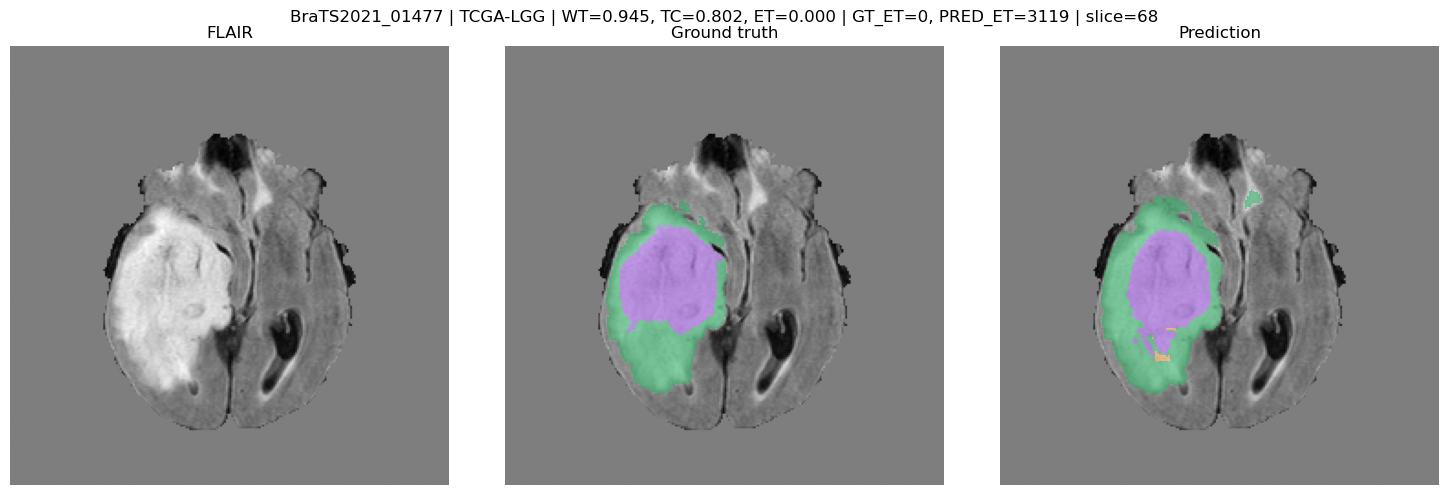

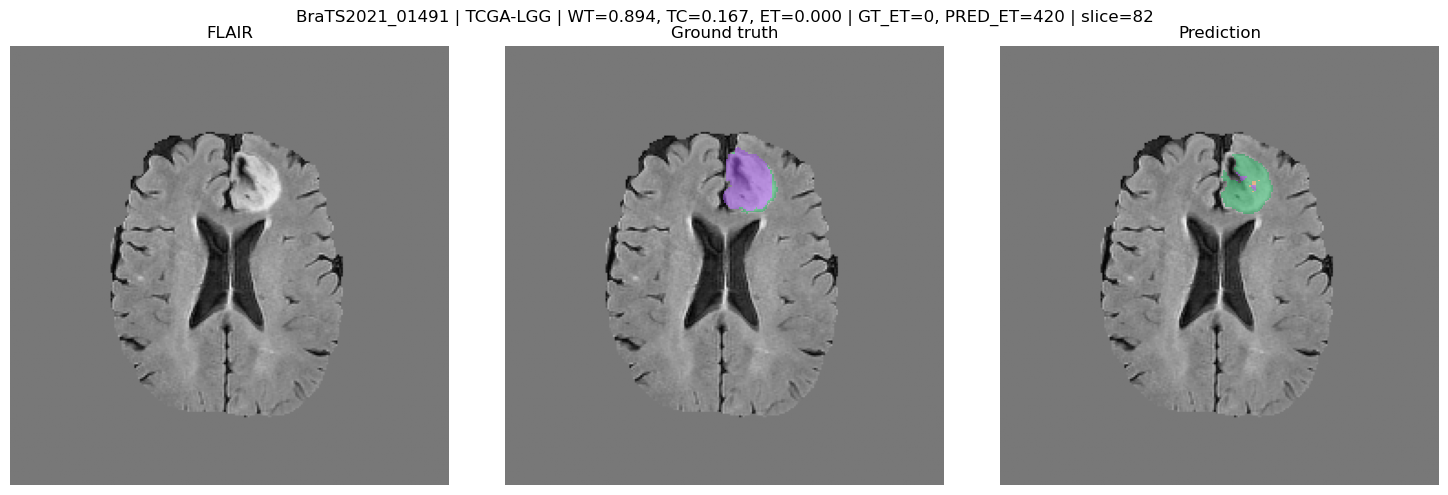

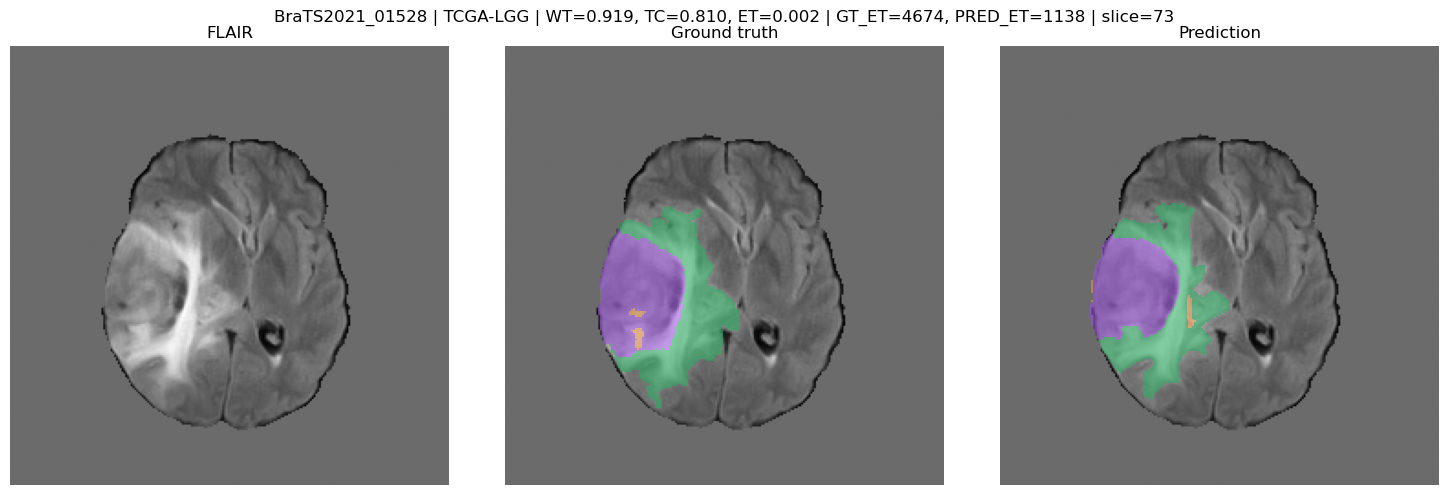

In [37]:
if len(tcga_lgg_bad_ids) == 0:
    print("No TCGA-LGG cases selected for visualization.")
else:
    for pid in tcga_lgg_bad_ids:
        rows = eval_df[eval_df["patient_id"] == pid]

        if len(rows) == 0:
            print(f"Skipping {pid}: not found in eval_df.")
            continue

        row = rows.iloc[0]

        case = load_full_case(row)
        pred = predict_full_volume(
            model=model,
            image_dhw=case["image_dhw"],
            device=device,
        )

        metrics_row = full_val_metrics[
            full_val_metrics["patient_id"] == pid
        ].iloc[0]

        title = (
            f"{pid} | {metrics_row['client_domain']} | "
            f"WT={metrics_row['dice_WT']:.3f}, "
            f"TC={metrics_row['dice_TC']:.3f}, "
            f"ET={metrics_row['dice_ET']:.3f} | "
            f"GT_ET={int(metrics_row['gt_ET_vox'])}, "
            f"PRED_ET={int(metrics_row['pred_ET_vox'])}"
        )

        show_full_prediction(case, pred, title=title)

# Optional comparison against a baseline experiment

In [38]:
baseline_path = CFG.get("baseline_metrics_abs") or CFG.get("baseline_metrics")

if baseline_path is None:
    print("No baseline_metrics configured. Skipping comparison.")
    cmp = None
else:
    if not os.path.exists(baseline_path):
        checked = "\n".join(str(p) for p in existing_path_candidates(CFG.get("baseline_metrics")))
        raise FileNotFoundError(
            f"Baseline metrics file not found: {baseline_path}\n"
            f"Configured: {CFG.get('baseline_metrics')}\n"
            f"Checked candidates:\n{checked}"
        )

    baseline_metrics = pd.read_csv(baseline_path)
    current_metrics = full_val_metrics.copy()

    base_suffix = CFG["baseline_suffix"]
    cur_suffix = CFG["experiment_suffix"]

    cmp = baseline_metrics.merge(
        current_metrics,
        on=["patient_id", "client_domain", "split"],
        suffixes=(f"_{base_suffix}", f"_{cur_suffix}"),
    )

    for metric in ["dice_WT", "dice_TC", "dice_ET"]:
        cmp[f"{metric}_delta"] = (
            cmp[f"{metric}_{cur_suffix}"] -
            cmp[f"{metric}_{base_suffix}"]
        )

    print("baseline:", CFG["baseline_name"])
    print("current:", CFG["experiment_name"])
    print("baseline_path:", baseline_path)
    print("merged cases:", len(cmp))

    display(
        cmp[[
            "dice_WT_delta",
            "dice_TC_delta",
            "dice_ET_delta",
        ]].mean()
    )

baseline: FedAvg SegResNet32 final CE-weighted — TEST
current: FedProx SegResNet32 final CE-weighted — TEST
baseline_path: /home/mandrakedrink/projects/research_ts_bs/models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
merged cases: 211


dice_WT_delta   -0.003651
dice_TC_delta   -0.003042
dice_ET_delta   -0.009145
dtype: float64

## Domain-level delta

In [39]:
if cmp is None:
    print("Comparison skipped because cmp is None.")
    domain_delta = None
else:
    domain_delta = (
        cmp.groupby("client_domain")[[
            "dice_WT_delta",
            "dice_TC_delta",
            "dice_ET_delta",
        ]]
        .mean()
        .reset_index()
    )

    display(domain_delta)

,client_domain,dice_WT_delta,dice_TC_delta,dice_ET_delta
0,TCGA-GBM,-0.009875,-0.021704,-0.017551
1,TCGA-LGG,0.000254,0.067821,-0.019987
2,UCSF-PDGM,-0.003880,-0.007897,-0.007959
3,UPENN-GBM,-0.002758,-0.004797,-0.006999


## Save comparison tables

In [40]:
if cmp is None:
    print("Comparison skipped; no files saved.")
else:
    cmp_path = os.path.join(
        CFG["save_dir"],
        f"{base_suffix}_vs_{cur_suffix}_comparison.csv",
    )

    domain_delta_path = os.path.join(
        CFG["save_dir"],
        f"{base_suffix}_vs_{cur_suffix}_domain_delta.csv",
    )

    cmp.to_csv(cmp_path, index=False)
    domain_delta.to_csv(domain_delta_path, index=False)

    print("saved:", cmp_path)
    print("saved:", domain_delta_path)

saved: models/federated_fedprox_segresnet32_final/full_volume_inference_test/fedavg_segresnet32_final_ceweighted_test_vs_fedprox_segresnet32_final_ceweighted_test_comparison.csv
saved: models/federated_fedprox_segresnet32_final/full_volume_inference_test/fedavg_segresnet32_final_ceweighted_test_vs_fedprox_segresnet32_final_ceweighted_test_domain_delta.csv


## Cases where the current experiment is worse than the baseline

In [41]:
if cmp is None:
    print("Comparison skipped because cmp is None.")
    worse_current_et = None
    worse_current_tc = None
    worse_current_wt = None
else:
    worse_current_et = cmp.sort_values("dice_ET_delta").head(15)
    worse_current_tc = cmp.sort_values("dice_TC_delta").head(15)
    worse_current_wt = cmp.sort_values("dice_WT_delta").head(15)

    display(worse_current_et)

,patient_id,client_domain,split,dice_WT_fedavg_segresnet32_final_ceweighted_test,dice_TC_fedavg_segresnet32_final_ceweighted_test,dice_ET_fedavg_segresnet32_final_ceweighted_test,gt_WT_vox_fedavg_segresnet32_final_ceweighted_test,gt_TC_vox_fedavg_segresnet32_final_ceweighted_test,gt_ET_vox_fedavg_segresnet32_final_ceweighted_test,pred_WT_vox_fedavg_segresnet32_final_ceweighted_test,...,abs_WT_vox_error_fedprox_segresnet32_final_ceweighted_test,abs_TC_vox_error_fedprox_segresnet32_final_ceweighted_test,abs_ET_vox_error_fedprox_segresnet32_final_ceweighted_test,pred_to_gt_ET_ratio_fedprox_segresnet32_final_ceweighted_test,gt_ET_size_bin,has_gt_ET,has_pred_ET,dice_WT_delta,dice_TC_delta,dice_ET_delta
199,BraTS2021_01545,UCSF-PDGM,test,0.892507,0.927918,0.909270,38243,7582,6687,45102,...,14426,4841,3781,1.565425,2001-10000,True,True,-0.072087,-0.253886,-0.236929
177,BraTS2021_01441,TCGA-GBM,test,0.854235,0.941011,0.897570,130288,53790,29915,171828,...,91963,15864,17095,1.571452,>10000,True,True,-0.122673,-0.149122,-0.209237
189,BraTS2021_01513,TCGA-LGG,test,0.938815,0.582377,0.736079,202427,153111,7070,195462,...,5448,75528,8392,2.186987,2001-10000,True,True,0.003845,0.043327,-0.163471
82,BraTS2021_00540,UCSF-PDGM,test,0.892463,0.152941,0.152941,12486,157,157,10455,...,3667,157,157,0.000000,1-500,True,False,-0.064864,-0.152941,-0.152941
32,BraTS2021_00239,UPENN-GBM,test,0.822610,0.914037,0.757355,68663,39210,5046,97795,...,35662,2925,4625,1.916568,2001-10000,True,True,-0.029376,-0.006372,-0.112522
174,BraTS2021_01387,UPENN-GBM,test,0.885659,0.584158,0.723567,92297,6752,5348,110998,...,20815,12704,4707,1.880142,2001-10000,True,True,-0.001141,-0.095605,-0.086028
163,BraTS2021_01314,UPENN-GBM,test,0.921067,0.822584,0.479871,70433,4866,3003,82064,...,18362,495,1797,0.401598,2001-10000,True,True,-0.042076,-0.009116,-0.084053
14,BraTS2021_00112,TCGA-GBM,test,0.933035,0.650624,0.536212,91751,16834,9523,95854,...,9867,16839,21139,3.219784,2001-10000,True,True,-0.026747,-0.079931,-0.083655
188,BraTS2021_01505,TCGA-LGG,test,0.915539,0.029371,0.830275,95449,67018,1072,102358,...,7503,65147,26,1.024254,501-2000,True,True,-0.008013,0.006194,-0.052395
121,BraTS2021_01047,UPENN-GBM,test,0.888156,0.922876,0.766444,143733,58252,20482,179753,...,40163,7913,14793,1.722244,>10000,True,True,-0.011310,-0.016232,-0.038607


In [42]:
if cmp is None:
    print("Comparison skipped; no worst-case comparison files saved.")
else:
    worse_current_et.to_csv(
        os.path.join(CFG["save_dir"], f"worse_{cur_suffix}_et_cases.csv"),
        index=False,
    )

    worse_current_tc.to_csv(
        os.path.join(CFG["save_dir"], f"worse_{cur_suffix}_tc_cases.csv"),
        index=False,
    )

    worse_current_wt.to_csv(
        os.path.join(CFG["save_dir"], f"worse_{cur_suffix}_wt_cases.csv"),
        index=False,
    )

    print("Saved worst-case comparison tables to:", CFG["save_dir"])

Saved worst-case comparison tables to: models/federated_fedprox_segresnet32_final/full_volume_inference_test
